# Notebook 4

In [1]:
# Imports
import numpy as np
import sys
sys.path.append("..")
from src.heat_kernel import estimate_heat_kernel, estimate_density, estimate_theoretical_heat_kernel
from src.manifolds.sphere import Sphere
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [2]:
# Record positions at chosen times on 2000 paths from fixed position
positions_at_times = estimate_heat_kernel()

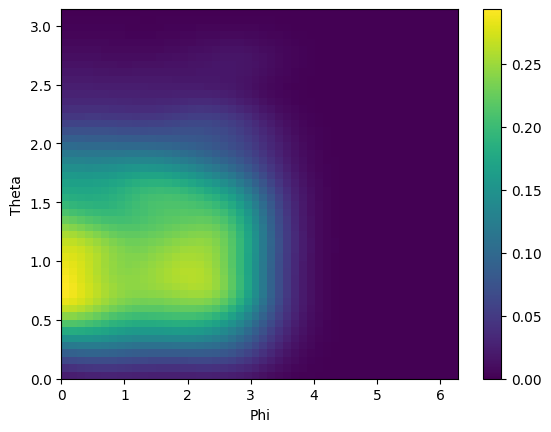

In [3]:
# Apply KDE with correct Riemannian volume normalization
times = [0.1, 0.5, 1.0, 2.0]
time_index = 2 # Corresponds to time 1.0
theta_grid, phi_grid, normalized_density_sphere, dtheta, dphi = estimate_density(positions_at_times, time_index)

# Display on heatmap
plt.imshow(normalized_density_sphere.T,
           origin="lower",
           extent=[0, 2*np.pi, 0, np.pi],
           aspect="auto")
plt.xlabel("Phi")
plt.ylabel("Theta")
plt.colorbar()
plt.show()

In [4]:
density = np.sum(normalized_density_sphere * np.sin(theta_grid) * dtheta * dphi)
assert np.isclose(density, 1.0, atol=0.001)
print(density)

1.0


In [5]:
# Animate spreading distribution on S^2 across time steps
# Create initial frame with the grids and normalized density
init_heatmap = go.Heatmap(
    x=phi_grid,
    y=theta_grid,
    z=normalized_density_sphere,
    colorscale="Viridis"
)

# Create frames for remaining time indices
heatmap_frames = []
for i in range(1, 4):
    theta_grid, phi_grid, normalized_density_sphere, dtheta, dphi = estimate_density(positions_at_times, i)
    z_frame = normalized_density_sphere
    heatmap_frames.append(
        go.Frame(
            data=[go.Heatmap(
                x=phi_grid,
                y=theta_grid,
                z=z_frame)],
            name=f"Time step: {times[i]}"
        )
    )

# Plot figure with all frames and a play button for animation
figure = go.Figure(
    data=[init_heatmap],
    frames=heatmap_frames,
    layout=go.Layout(
        title="Spreading Distribution on Sphere",
        xaxis=dict(title="Phi"),
        yaxis=dict(title="Theta"),
        updatemenus=[{
            "type": "buttons",
            "buttons": [
                {
                    "label": "Play",
                    "method": "animate",
                    "args": [
                        None,
                        {
                            "frame": {"duration": 600, "redraw": True}, # Set redraw to true to prevent frozen animation
                            "fromcurrent": True,
                            "transition": {"duration": 200}
                        }
                    ]
                }
            ]
        }]
    )
)

figure.show()

In [6]:
# Calculate theoretical heat kernel densities
theoretical_densities = []
for t in times:
    theoretical_density = estimate_theoretical_heat_kernel(theta_grid, phi_grid, t)
    theoretical_densities.append(theoretical_density)

In [7]:
# Create initial theoretical contour
init_theoretical_contour = go.Contour(
    x=phi_grid,
    y=theta_grid,
    z=theoretical_densities[0],
    contours=dict(coloring="none"),
    showscale=False
)

In [8]:
overlayed_frames = []
for i in range(1, 4):
    theta_grid, phi_grid, normalized_density_sphere, dtheta, dphi = estimate_density(positions_at_times, i)
    z_frame = normalized_density_sphere
    
    theoretical_contour = go.Contour(
        x=phi_grid,
        y=theta_grid,
        z=theoretical_densities[i],
        contours=dict(coloring="none"),
        showscale=False
    )
    
    overlayed_frames.append(
        go.Frame(
            data=[go.Heatmap(
                x=phi_grid,
                y=theta_grid,
                z=z_frame
                ),
                theoretical_contour
            ],
            name=f"Time step: {times[i]}"
        )
    )


# Plot figure with all frames and a play button for animation
figure = go.Figure(
    data=[init_heatmap, init_theoretical_contour],
    frames=overlayed_frames,
    layout=go.Layout(
        title="Spreading Distribution on Sphere",
        xaxis=dict(title="Phi"),
        yaxis=dict(title="Theta"),
        updatemenus=[{
            "type": "buttons",
            "buttons": [
                {
                    "label": "Play",
                    "method": "animate",
                    "args": [
                        None,
                        {
                            "frame": {"duration": 600, "redraw": True}, # Set redraw to true to prevent frozen animation
                            "fromcurrent": True,
                            "transition": {"duration": 200}
                        }
                    ]
                }
            ]
        }]
    )
)

figure.show()